<a href="https://colab.research.google.com/github/Prosper397/analyse-ventes-retail/blob/main/analyse_ventes_retail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd               # Equivalent d'excel, mais en code
import matplotlib.pyplot as plt    # bibliothèque de visualisation
import seaborn as sns


# Lisons le fichier excel

df = pd.read_csv("/content/online_retail.csv")

# Affichons le nbre de lignes et de colonnes du tableau
print(f"Dimensions : {df.shape}")

# Affichons les 5 1ères lignes du tableau

Dimensions : (375291, 8)


In [2]:
# Types de données + valeurs nulles

print(df.dtypes)
print("\nValeurs nulles par colonne : ")
print(df.isnull().sum())

InvoiceNo       object
StockCode       object
Description     object
Quantity       float64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

Valeurs nulles par colonne : 
InvoiceNo          0
StockCode          0
Description     1273
Quantity           1
InvoiceDate        1
UnitPrice          1
CustomerID     98773
Country            1
dtype: int64


In [3]:
# Supprimons les colonnes sans CustomerID
df = df.dropna(subset=['CustomerID'])

# Supprimons les retours clients(quantités négatives)
df = df[df['Quantity'] > 0]

# Supprimons les prix à 0
df = df[df['UnitPrice'] > 0]

# Convertissons InvoiceDate en vrai format date
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Créons la colonne Revenue(ce qu'on a vraiment gagné)
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Vérifions le résultat
print(f"Lignes après néttoyage : {len(df)}")
df.head()

Lignes après néttoyage : 270107


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [4]:
# Place à l'analyse

# Top 10 produits par Revenu
top_produits = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

print(top_produits)

# ventes par mois
df['Month'] = df['InvoiceDate'].dt.to_period('M')
ventes_mois = df.groupby('Month')['Revenue'].sum()

print(ventes_mois)

# Top 10 pays par revenu
ventes_pays = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

print(ventes_pays)


Description
REGENCY CAKESTAND 3 TIER              115728.34
MEDIUM CERAMIC TOP STORAGE JAR         80236.44
WHITE HANGING HEART T-LIGHT HOLDER     80197.08
JUMBO BAG RED RETROSPOT                62864.77
PARTY BUNTING                          62471.12
POSTAGE                                56754.51
ASSORTED COLOUR BIRD ORNAMENT          42159.23
PICNIC BASKET WICKER 60 PIECES         39619.50
Manual                                 32294.78
CHILLI LIGHTS                          30713.37
Name: Revenue, dtype: float64
Month
2010-12    572713.890
2011-01    569445.040
2011-02    447137.350
2011-03    595500.760
2011-04    469200.361
2011-05    678594.560
2011-06    661213.690
2011-07    600091.011
2011-08    645343.900
2011-09    952838.382
2011-10     87758.790
Freq: M, Name: Revenue, dtype: float64
Country
United Kingdom    5117801.604
Netherlands        207135.660
EIRE               204775.650
Germany            161219.530
France             137477.190
Australia          114128.060
Spa

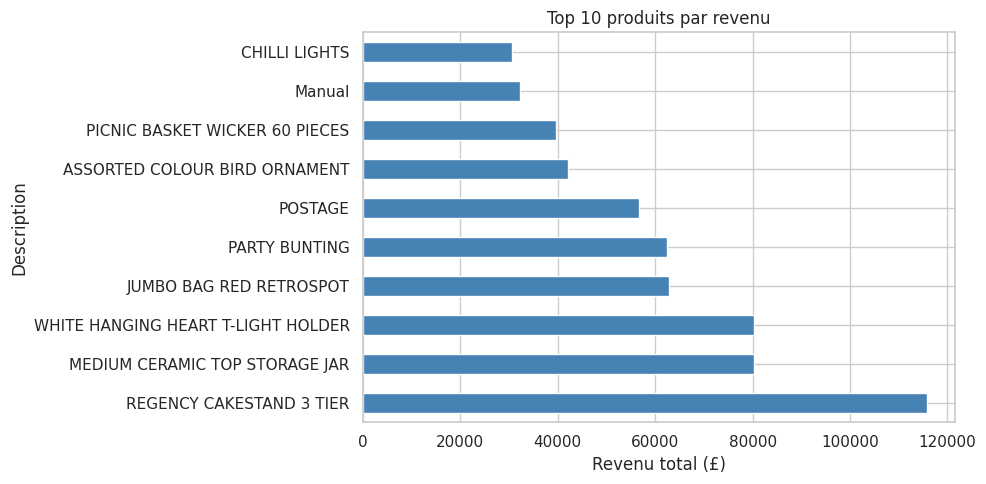

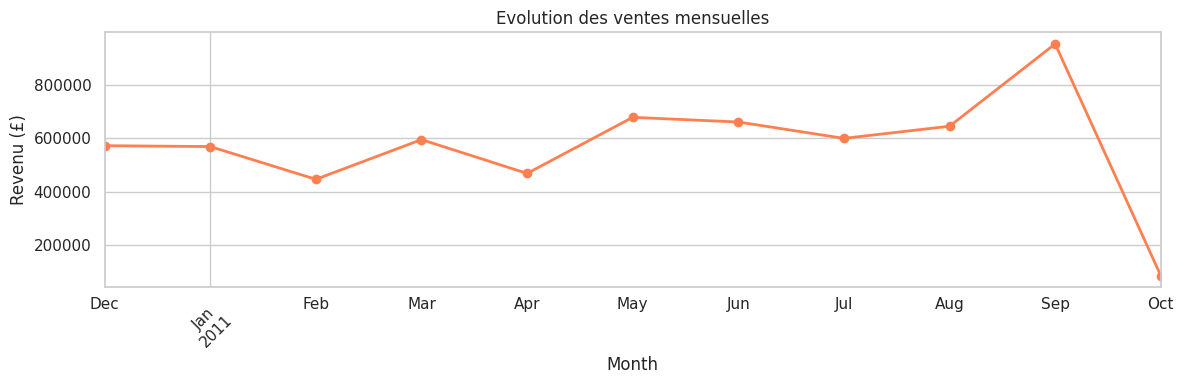

In [5]:
# Transformons tout ça maintenant en graphiques

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 5))
top_produits.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title("Top 10 produits par revenu")
ax.set_xlabel("Revenu total (£)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
ventes_mois.plot(ax=ax, color='coral', linewidth=2, marker='o')
ax.set_title("Evolution des ventes mensuelles")
ax.set_ylabel("Revenu (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

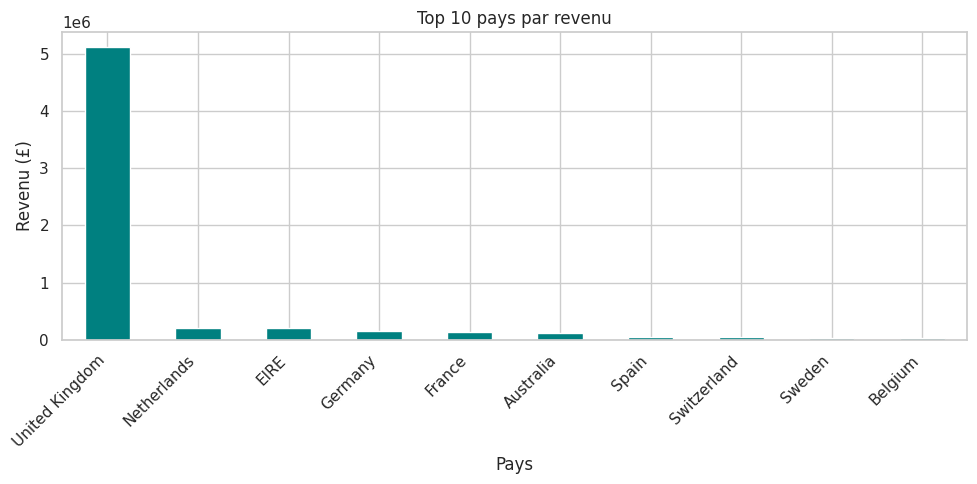

In [7]:
# Graphique montrant le top pays
fig, ax = plt.subplots(figsize=(10, 5))
ventes_pays.plot(kind='bar', ax=ax, color='teal')
ax.set_title("Top 10 pays par revenu")
ax.set_ylabel("Revenu (£)")
ax.set_xlabel("Pays")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()